# GRPO Subject-Verb Relationship Extraction RL Notebook

Train Llama-3.1-8B-Instruct to extract subject-verb relationships in format `{"entity": "...", "action": "..."}` using Group Relative Policy Optimization (GRPO). Reward: format payoff + penalty for verbose output outside the subject-verb pair.

**Run on a separate Colab instance** (e.g. A100). Paste the final prompt from Stage A (full_project.ipynb) to use the multi-agent-improved prompt. Saves model to Drive for use in full_project.ipynb.

**Run cells in order.** Designed for Google Colab.

## 1. Setup: Mount Drive and Install Dependencies

In [1]:
# Mount Google Drive (Colab) - skip if running locally
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not in Colab - skipping Drive mount. Use local data path.")

# Install dependencies
!pip -q install trl transformers datasets accelerate gdown openai

# Download data if not on Drive
import os
data_path = "/content/drive/MyDrive/original_content_trump_motifs_en_10k.csv"
if not os.path.exists(data_path):
    !gdown --fuzzy "https://drive.google.com/file/d/16i1OAEW1jH1oGeJVrIZzyfvD_MoXybMF/view?usp=sharing" -O /content/original_content_trump_motifs_en_10k.csv
    data_path = "/content/original_content_trump_motifs_en_10k.csv"
print(f"Data path: {data_path}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 18.9 MB/s eta 0:00:00
Data path: /content/drive/MyDrive/original_content_trump_motifs_en_10k.csv


## 2. Imports

In [2]:
# Add project path (Colab: cwd has modules/; local: run from final_project)
import sys
import os
sys.path.insert(0, os.getcwd())

# # Optional: upload module files in Colab to update
# if 'google.colab' in sys.modules:
#     from google.colab import files
#     print("Upload module files to update (optional - click Cancel to skip):")
#     try:
#         uploaded = files.upload()
#         if uploaded:
#             os.makedirs('modules', exist_ok=True)
#             for name, content in uploaded.items():
#                 if name.endswith('.py'):
#                     with open(os.path.join('modules', name), 'wb') as f:
#                         f.write(content)
#                     print(f"Updated modules/{name}")
#     except Exception:
#         pass

# Upload modules using VS Code's Google Colab extension
from modules.llama_RL import (
    load_motifs_for_rl,
    make_motif_reward_func,
    run_grpo_train,
    save_model_to_drive,
    build_prompt_from_autogen,
    plot_dataset_overview,
    plot_reward_accuracy,
    plot_training_summary,
    plot_loss_curve,
    plot_reward_over_training,
    plot_format_compliance,
    plot_pre_post_comparison,
    get_sample_outputs,
    DEFAULT_PROMPT_TEMPLATE,
)

## Force reload

In [3]:
import importlib

# Force reload the llama_RL module to pick up latest changes
importlib.invalidate_caches()
import modules.llama_RL
importlib.reload(modules.llama_RL)

from modules.llama_RL import (
    load_motifs_for_rl,
    make_motif_reward_func,
    run_grpo_train,
    save_model_to_drive,
    build_prompt_from_autogen,
    plot_dataset_overview,
    plot_reward_accuracy,
    plot_training_summary,
    plot_loss_curve,
    plot_reward_over_training,
    plot_format_compliance,
    plot_pre_post_comparison,
    get_sample_outputs,
    DEFAULT_PROMPT_TEMPLATE,
)

In [4]:
# Output columns for extraction (must match CSV columns besides 'text')
output_columns = ["entity", "action"]

## 3. Config

## 3b. Prompt from Stage A (Optional)

Paste the final prompt from full_project.ipynb Stage A here. If left empty, uses DEFAULT_PROMPT_TEMPLATE.

In [5]:
# Updated prompt from stage A, with output format adapted to RL task
prompt_from_autogen = 'You are tasked with extracting structured information from provided text snippets concerning the person "Trump". Your goal is to identify and extract two key components: the "Entity" and the "Action". \n\n**Extraction Task**:\n1. **Entity**: This should be any mention of "Trump", including variations such as "Trump", "Donald Trump", or "DJT". Ensure the entity is always capitalized correctly, using "Trump" as the standard form in your output.\n2. **Action**: Identify a verb that describes what the entity is doing. The action must be in its base form (e.g., "stand", "announce", "reveal") and written in lowercase.\n\n**Output Format**: Your output must strictly adhere to the following JSON structure: {"entity": "...", "action": "..."}\n\n\nFor example, if the input text is "Trump signed a new law", your output should be:{"entity": "Trump", "action": "sign"}\n\n\n**Instructions for Matching Annotation Conventions**:\n- Always use the variation found in the text (e.g., "Trump", "DJT", etc.) for the entity.\n- The action should be a succinct verb that captures the essence of what the entity is doing, without any alterations or additional context.\n- Ensure consistency in casing: the entity name must be capitalized, while the action must be in lowercase.\n\n**Handling Edge Cases**:\n- If multiple entities or actions are present, extract only the first entity and the first action mentioned in the text.\n- If the action is unclear or cannot be determined, respond with "unknown".\n- Maintain the same output structure regardless of the context or complexity of the text.\n\n**Reinforcement of Style**: Follow the provided examples closely without deviation. Your goal is to replicate the annotation patterns exactly as outlined here. Any variations in format or interpretation will not be acceptable.'

if prompt_from_autogen and prompt_from_autogen.strip():
    prompt_template = build_prompt_from_autogen(prompt_from_autogen.strip(), output_columns)
    print("Using prompt converted from AutoGen Stage A")
else:
    prompt_template = DEFAULT_PROMPT_TEMPLATE
    print("Using DEFAULT_PROMPT_TEMPLATE")

Using prompt converted from AutoGen Stage A


In [6]:
# Tunable parameters (prompt_template set in cell above)
n_rows = 500                    # Number of rows from 10k dataset (tune for faster/slower runs)
train_output_dir = "./drive/MyDrive/llama_rl/grpo_motif_output"   # Local dir for training checkpoints
save_to_drive_path = "MyDrive/llama_rl/llama_motif_grpo"  # Save path on Drive (for save_model_to_drive; /content/drive/ are appended later)
model_name = "meta-llama/Llama-3.1-8B-Instruct"
num_generations = 4              # GRPO group size
num_train_epochs = 2.0
per_device_train_batch_size = 2

## 4. Load Data and Visualize

/content/drive/MyDrive/original_content_trump_motifs_en_10k.csv
Loaded 153 examples
Sample prompt: You are a highly efficient information detection and extraction engine, specialized in analyzing natural language data.
You value accuracy: when the user asks you to extract certain information from g ...


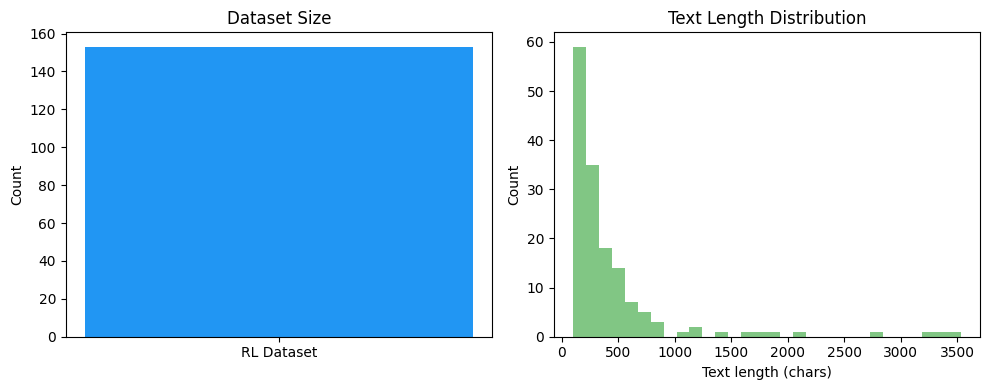

In [7]:
# Resolve data path
data_path = "/content/drive/MyDrive/original_content_trump_motifs_en_10k.csv"
if not os.path.exists(data_path):
    data_path = "/content/original_content_trump_motifs_en_10k.csv"

print(data_path)

dataset = load_motifs_for_rl(
    path=data_path,
    n_rows=n_rows,
    prompt_template=prompt_template,
    prompt_from_autogen=prompt_from_autogen.strip() if (prompt_from_autogen and prompt_from_autogen.strip()) else None,
    output_columns=output_columns,
)

print(f"Loaded {len(dataset)} examples")
print("Sample prompt:", dataset[0]["prompt"][0]["content"][:200], "...")

# Visualization: dataset overview
plot_dataset_overview(dataset)

## 5. Define Reward Function

In [ ]:
# Original RL reward: format payoff for valid JSON, penalty for text outside JSON
reward_func = make_motif_reward_func(
    output_columns=output_columns,
    format_payoff=1.0,       # +1.0 when output contains valid JSON with entity, action
    penalty_per_char=0.002,   # -0.002 per character outside the JSON block
    content_bonus=2.0       # +2.0 bonus when extracted values match ground truth 
)
print(
    "Reward settings: +" + str(2.0) +
    " bonus for correct extraction, +" + str(1.0) +
    " for valid JSON."
)

Reward settings: +2.0 bonus for correct extraction, +1.0 for valid JSON, -0.002 per character outside the JSON block.


[motif_reward] First batch (n=100): 100 samples have non-empty ground truth. content_bonus=active
Ranking accuracy: 100.0%


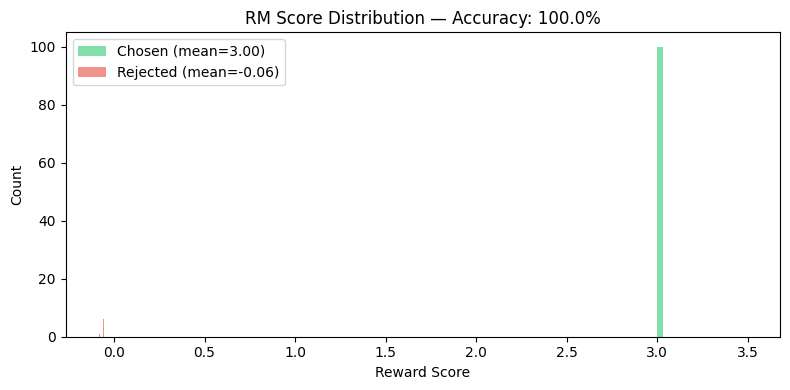

In [9]:
# Reward accuracy: chosen (valid JSON) vs rejected (non-JSON) — mirrors RL reward
plot_reward_accuracy(dataset, reward_func, output_columns=output_columns, n_samples=100)

## 6. Train

**Note:** Llama models require Hugging Face authentication. The cell below will ask you for your token to enable access.

**If you get OOM:** Restart the runtime (Runtime → Restart) before running again — a previous failed run may have left the model in GPU memory. If OOM persists, try `num_generation=2` and `per_device_train_batch_size=2` in the config cell.

In [10]:
from huggingface_hub import login
from getpass import getpass
hf_token = getpass("Enter your HuggingFace token: ")
login(token=hf_token)

In [11]:
trainer = run_grpo_train(
    train_dataset=dataset,
    model_name=model_name,
    output_dir=train_output_dir,
    reward_funcs=reward_func,
    prompt_template=prompt_template,
    n_rows=n_rows,
    num_generation=num_generations,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    logging_steps=10,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.
Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Step,Training Loss
10,0.019088
20,0.156732
30,0.141247
40,0.179183
50,0.302928
60,0.170971
70,0.353948
80,0.084942
90,0.114836
100,0.037261


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=306, training_loss=0.10498003843940454, metrics={'train_runtime': 2089.7854, 'train_samples_per_second': 0.146, 'train_steps_per_second': 0.146, 'total_flos': 0.0, 'train_loss': 0.10498003843940454})

## 7. Visualizations (full variety - select best for reporting)

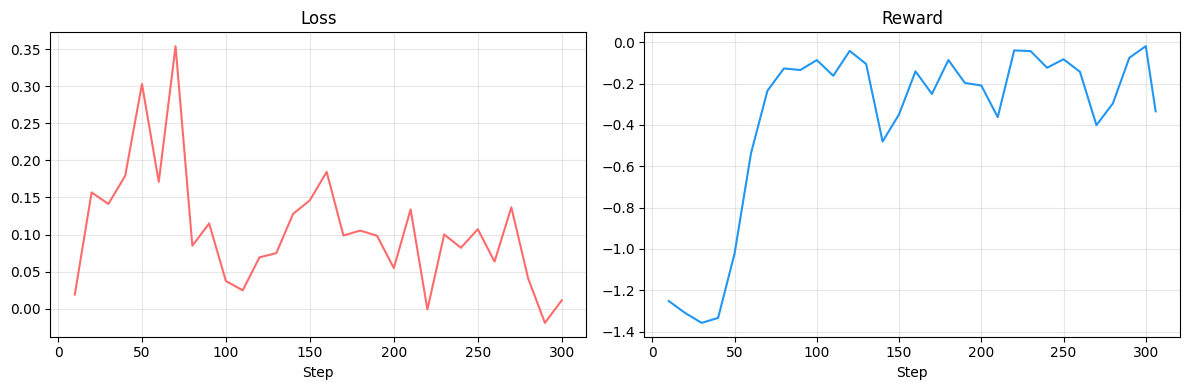

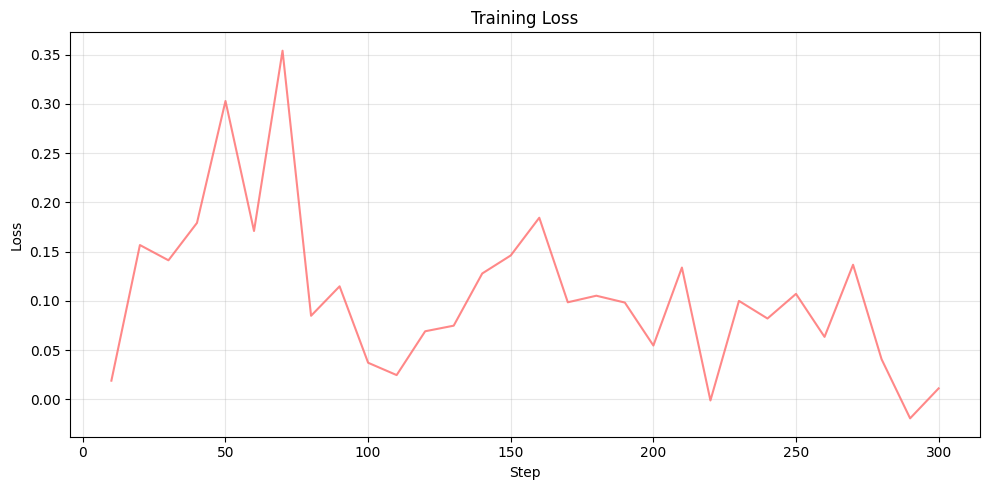

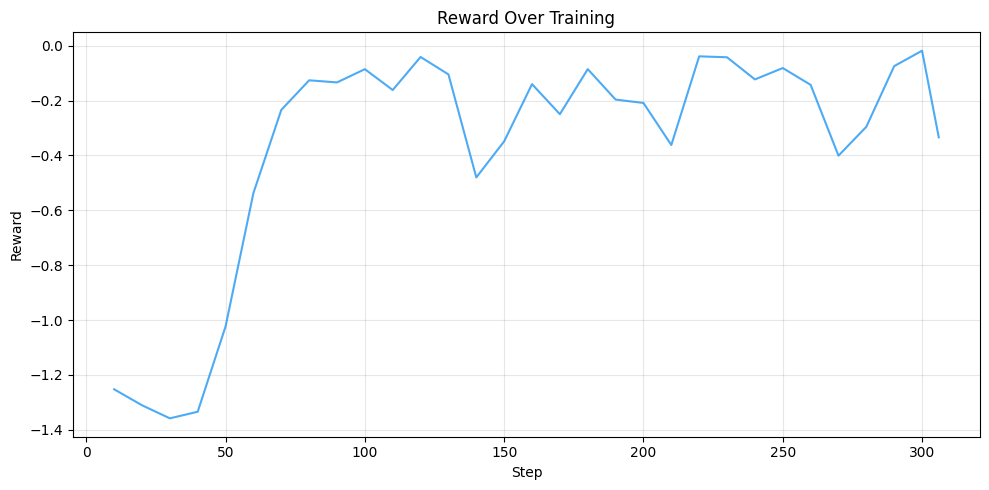

In [12]:
# Plot 1: Training summary (loss + reward)
plot_training_summary(trainer)

# Plot 2: Loss curve
plot_loss_curve(trainer)

# Plot 3: Reward over training
plot_reward_over_training(trainer)

### Format compliance

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


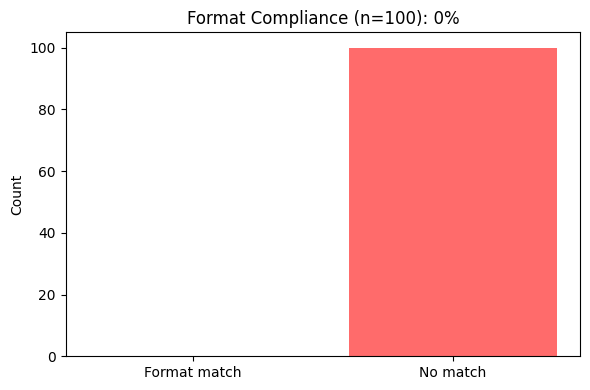

In [13]:
plot_format_compliance(dataset, trainer.model, trainer.processing_class, n_samples=100)

### Sample outputs (qualitative inspection)

In [14]:
# Sample outputs from trained model (qualitative review)
samples = get_sample_outputs(dataset, trainer.model, trainer.processing_class, n_samples=5)
for i, s in enumerate(samples):
    print(f"--- Sample {i+1} ---")
    print(f"Entity: {s['entity']}, Action: {s['action']}")
    print(f"Output: {print(s['output'])}...")
    print()

--- Sample 1 ---
Entity: Trump, Action: win
 
 +:+ fetisch000 für fetisch aalborg geschichten‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍
Output: None...

--- Sample 2 ---
Entity: Trump, Action: know
 
 +:+	UObject aalborg geschichten‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍
Output: None...

--- Sample 3 ---
Entity: Donald Trump, Action: share
 
| 百度 百度‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍
Output: None...

--- Sample 4 ---
Entity: Trump, Action: leave
 

 +:+ sourceMapping odense‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍
Output: None...

--- Sample 5 ---
Entity: Donald Trump, Action: pound
 This aalborg salopes000 entre aalborg000 dass aalborg fetisch‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍

## 8. RATE: What Does the Reward Actually Reward?

RATE (Rewrite-based Attribute Treatment Estimators) measures how text attributes affect reward scores. For each attribute, we add it then remove it via GPT rewrites, and compare scores. Sample prompts = RL prompt template + 10 random texts from the dataset. Requires OpenAI API key.

In [15]:
from openai import OpenAI
import getpass

openai_api_key = getpass.getpass("Please enter your OpenAI API key: ")
client = OpenAI(api_key=openai_api_key)


Attribute: coherent
  You are tasked with extracting structured informat... | +coherent=1.000, -coherent=0.000
  You are tasked with extracting structured informat... | +coherent=1.000, -coherent=0.000
  You are tasked with extracting structured informat... | +coherent=1.000, -coherent=0.000
  You are tasked with extracting structured informat... | +coherent=1.000, -coherent=0.000
  You are tasked with extracting structured informat... | +coherent=1.000, -coherent=0.000
  You are tasked with extracting structured informat... | +coherent=1.000, -coherent=0.000
  You are tasked with extracting structured informat... | +coherent=1.000, -coherent=0.000
  You are tasked with extracting structured informat... | +coherent=1.000, -coherent=0.000
  You are tasked with extracting structured informat... | +coherent=1.000, -coherent=0.000
  You are tasked with extracting structured informat... | +coherent=1.000, -coherent=0.000
  ATE(coherent) = 1.0000 +/- 0.0000

Attribute: analytical
  You are 

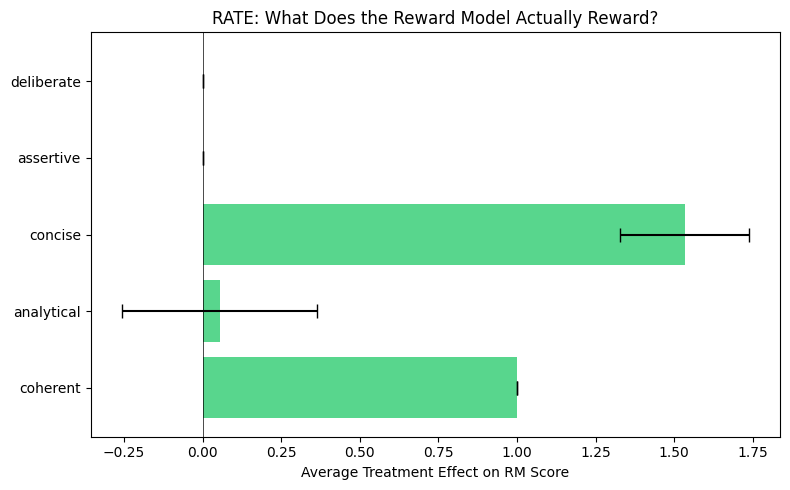

In [17]:
import numpy as np
import random
import matplotlib.pyplot as plt

def rewrite_text(client, text, instruction):
    return client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"{instruction}\n\nOriginal text:\n{text}"}],
        max_tokens=500,
    ).choices[0].message.content

def generate_response(client, prompt):
    return client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300,
    ).choices[0].message.content

def score_response(reward_func, row, response):
    """Score a completion using the motif reward function."""
    return reward_func(completions=[response], entity=[row["entity"]], action=[row["action"]])[0]

attributes = {
    "coherent": {
        "add": "Rewrite to be more coherent and linguistically well-formed, keeping the core meaning.",
        "remove": "Rewrite to be less coherent, introducing garbled phrasing, broken syntax, or nonsensical word choices, while loosely preserving the core meaning.",
    },
    "analytical": {
        "add": "Rewrite to be significantly more analytical and detailed, keeping the core meaning.",
        "remove": "Rewrite to be more vague and general, keeping the core meaning.",
    },
    "concise": {
        "add": "Rewrite in a much more concise and to-the-point manner, keeping the core meaning.",
        "remove": "Rewrite in a more verbose and detailed manner, keeping the core meaning.",
    },
    "assertive": {
        "add": "Rewrite to be more assertive and confident, keeping the core meaning.",
        "remove": "Rewrite to be more humble and modest, keeping the core meaning.",
    },
    "deliberate": {
        "add": "Rewrite to be more deliberate and thoughtful, keeping the core meaning.",
        "remove": "Rewrite to be more impulsive and spontaneous, keeping the core meaning.",
    },
}

# 10 sample prompts = RL prompt template + random text from dataset
n_samples = min(10, len(dataset))
sample_indices = random.sample(range(len(dataset)), n_samples)
sample_prompts = []
sample_rows = []
for idx in sample_indices:
    row = dataset[int(idx)]
    sample_rows.append(row)
    prompt = prompt_template.format(text=row["text"])
    sample_prompts.append(prompt)

rate_results = {}
for attr_name, attr_config in attributes.items():
    print(f"\n{'='*40}\nAttribute: {attr_name}\n{'='*40}")
    treated_scores, untreated_scores = [], []

    for prompt, row in zip(sample_prompts, sample_rows):
        original = generate_response(client, prompt)
        rewrite_add = rewrite_text(client, original, attr_config["add"])
        rewrite_remove = rewrite_text(client, rewrite_add, attr_config["remove"])

        score_add = score_response(reward_func, row, rewrite_add)
        score_remove = score_response(reward_func, row, rewrite_remove)

        treated_scores.append(score_add)
        untreated_scores.append(score_remove)
        print(f"  {prompt[:50]}... | +{attr_name}={score_add:.3f}, -{attr_name}={score_remove:.3f}")

    ate = np.mean(treated_scores) - np.mean(untreated_scores)
    se = np.sqrt(np.var(treated_scores, ddof=1)/len(treated_scores) + np.var(untreated_scores, ddof=1)/len(untreated_scores))
    rate_results[attr_name] = {"ate": ate, "se": se}
    print(f"  ATE({attr_name}) = {ate:.4f} +/- {se:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
attrs = list(rate_results.keys())
ates = [rate_results[a]["ate"] for a in attrs]
ses = [rate_results[a]["se"] for a in attrs]
colors = ["#e74c3c" if a < 0 else "#2ecc71" for a in ates]
ax.barh(attrs, ates, xerr=ses, color=colors, alpha=0.8, capsize=5)
ax.set_xlabel("Average Treatment Effect on RM Score")
ax.set_title("RATE: What Does the Reward Model Actually Reward?")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 10. Save Model to Drive

**NOTE**: Unused because reinforced model was not functional.

In [ ]:
# Save reinforced model to Drive for later use with SGLang
saved_path = save_model_to_drive(trainer, output_dir=save_to_drive_path)
print(f"Model saved to: {saved_path}")
print()
print("="*60)
print("NEXT: Use this model in full_project.ipynb")
print("="*60)
print("1. In full_project.ipynb Section 3, set rl_model_path =", repr(saved_path))
print("2. Start SGLang with: --model-path", saved_path)
print("3. Run Stage C (DSPy) and Stage D (MCP) with the RL-trained model")